# Análise Descritiva — Employment with Offer (Synthetic)

## Introdução

Este notebook faz a **análise descritiva** do dataset sintético `employment-with-offer-synthetic.csv`,
que reúne registros de contratação (*employment*) e suas respectivas propostas (*offer*) em uma
plataforma de emprego global (EOR — *Employer of Record*): dados cadastrais do colaborador, da
proposta enviada, do processo de onboarding e das condições contratuais (salário, carga horária,
período de experiência, aviso prévio, entre outros).

**Problema que este notebook apoia:** entender o perfil geral da base e como os principais
atributos (país, moeda, frequência de pagamento, tipo de solução, salário, carga horária etc.) se
relacionam com o **status da contratação** (`status`) e com o **status do onboarding**
(`onboarding_status`) — ambos já existentes na base. Nenhuma categoria nova é criada para isso
(por exemplo, não derivamos um agrupamento tipo "WIN/LOSS"): usamos os valores de status tal
como estão gravados na base.

**Escopo:** estatística descritiva — tendência central, dispersão, distribuição de variáveis
categóricas e numéricas, e qualidade dos dados (nulos e duplicados). Não há engenharia de
atributos nem modelagem preditiva; uma investigação mais aprofundada (testes de associação,
atributos derivados) já existe em `nb_employment_offer_analysis.ipynb`.

## Importação das Bibliotecas

In [641]:
pip install numpy pandas matplotlib seaborn

You should consider upgrading via the '/Users/filipesilva/Documents/datascience/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [642]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
ACCENT = '#4C72B0'
plt.rcParams['figure.dpi'] = 100

print('Bibliotecas prontas.')

Bibliotecas prontas.


## Carregamento dos Dados

In [643]:
# ── Google Colab: montar o Drive se estiver rodando lá ─────────────────────
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # ↓ ajuste para o local onde você colocou o arquivo no Drive
    FILE_PATH = '/content/drive/MyDrive/datascience/files/employment-with-offer-synthetic.csv'
else:
    # local / qualquer outro kernel
    FILE_PATH = './data/employment-with-offer-synthetic.csv'

print(f'File path: {FILE_PATH}')

File path: ./data/employment-with-offer-synthetic.csv


In [644]:
df = pd.read_csv(
    FILE_PATH,
    low_memory=False,
    on_bad_lines='warn',   # avisa sobre linhas malformadas de campos multi-linha
)
print(f'Carregado  →  {df.shape[0]:,} linhas  ×  {df.shape[1]} colunas')

Carregado  →  73,852 linhas  ×  125 colunas


## Conhecendo a Base

Antes de qualquer estatística, olhamos a estrutura da base: tipos de dado, completude (nulos)
e se há registros duplicados.

### Estrutura e Tipos das Variáveis

In [645]:
df.head()

,numberId,id,employeeUserId,companyId,country,updatedAt,updatedBy,createdAt,createdBy,employingEntityId,...,offer_isOfferingSignOnBonus,offer_signOnBonusAmount,offer_noticePeriodTerm,offer_noticePeriodLength,offer_initialHourlyRate,offer_initialAnnualSalaryInContractCurrency,offer_retirementMatchType,offer_retirementMatchPercentage,offer_retirementMatchAmount,offer_variableCompensationTypes
0,25296,emp_6dEn01z5kG3bWwBuMEfkRP,user_40Y33sOxlPtpVRMReHEek5,cmp_vm1e1arp1cpnq1c1cqrnt1,NL,2026-04-28 14:06:35.000,54151,2024-09-17 19:28:14.000,54151,cmp_uont1bqvon1eovq1euquqo,...,NaN,NaN,days,30.0,NaN,105000.0,NaN,NaN,NaN,NaN
1,8590,emp_1DX67yg772qMFWVOiFn9Dl,user_1en1ev1a1e1e1e1c1e1bnq,cmp_1cp1eon1c1en1b1Z1bpqp1,SG,2026-04-28 14:06:35.000,54151,2021-10-07 15:52:15.000,54151,cmp_1apqmsq1dvq1btnqmqqu1Z,...,NaN,NaN,weeks,1.0,NaN,408.0,NaN,NaN,NaN,NaN
2,19420,emp_643doZHZwdd33KLJ0S5aCr,user_1en1ev1a1e1e1e1c1e1bnq,cmp_1cp1eon1c1en1b1Z1bpqp1,SG,2026-04-28 14:06:35.000,54151,2023-03-29 19:08:53.000,54151,cmp_uont1bqvon1eovq1euquqo,...,NaN,NaN,weeks,1.0,NaN,408.0,NaN,NaN,NaN,NaN
3,16956,emp_6aToSEspn3UNQxdXB8DW19,user_o1Z1dm1etv1a1drorqpppu,cmp_o1crvp1erqm1ar1eqsqtvm,DO,2026-04-28 14:06:35.000,54151,2022-10-13 16:55:03.000,54151,cmp_1c1Z1d1d1cp1em1Z1bn1aq,...,NaN,NaN,NaN,NaN,NaN,3496376.0,NaN,NaN,NaN,NaN
4,22745,emp_0KZSt6qiEk5cQLTTyNoQO3,user_v1drp1Z1c1cp1bnq1aq1dq,cmp_mrpoovn1Zvm1a1eqov1a1a,PH,2026-04-28 14:06:35.000,54151,2024-01-18 16:53:18.000,54151,cmp_uont1bqvon1eovq1euquqo,...,NaN,NaN,days,0.0,NaN,937769.0,NaN,NaN,NaN,NaN


In [646]:
print('Contagem de colunas por tipo de dado:')
print(df.dtypes.value_counts())

Contagem de colunas por tipo de dado:
object     85
float64    34
int64       3
bool        3
Name: count, dtype: int64


In [647]:
resumo_colunas = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().mean() * 100).round(1),
    'valores_unicos': df.nunique(),
})
resumo_colunas

,dtype,nulos,nulos_%,valores_unicos
numberId,int64,0,0.0,40669
id,object,0,0.0,51986
employeeUserId,object,0,0.0,50163
companyId,object,0,0.0,6822
country,object,0,0.0,162
...,...,...,...,...
offer_initialAnnualSalaryInContractCurrency,float64,20467,27.7,11284
offer_retirementMatchType,object,67450,91.3,1
offer_retirementMatchPercentage,float64,66385,89.9,22
offer_retirementMatchAmount,float64,73852,100.0,0


In [648]:
print('status == engagementStatus em todas as linhas?', (df['status'] == df['engagementStatus']).all())

status == engagementStatus em todas as linhas? True


> **Observações sobre os tipos**
>
> - `status` e `engagementStatus` são **idênticas em 100% das linhas** (confirmado acima) — uma
>   delas é redundante para fins de análise; usamos apenas `status` daqui em diante.
> - Vários campos com dtype `float64` são, na verdade, **identificadores** (ex.: `onboarding_id`,
>   `offer_id`, `offer_companyAddressId`) — o pandas os lê como número só porque têm valores
>   ausentes; eles não fazem parte da análise numérica a seguir.
> - Colunas de data (`createdAt`, `updatedAt`, `startAt`, `endAt`, `anticipatedStartDate`,
>   `offer_insertedAt`, entre outras) estão armazenadas como texto (`object`), não como data —
>   o pandas não as interpreta automaticamente como tal.

### Valores Ausentes

In [649]:
nulos = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
nulos[nulos > 0].to_frame('nulos_%').head(30)

,nulos_%
offer_retirementMatchAmount,100.0
offer_additionalAnnualLeaveDays,100.0
offer_annualLeaveCarryoverDays,100.0
hourlyRate,100.0
offer_employeeCurrentNoticeDays,100.0
offer_isGymAllowanceOffered,99.9
offer_isPhoneAllowanceOffered,99.9
offer_isCarAllowanceOffered,99.9
offer_isInternetAllowanceOffered,99.9
offer_flightAllowanceAmount,99.9


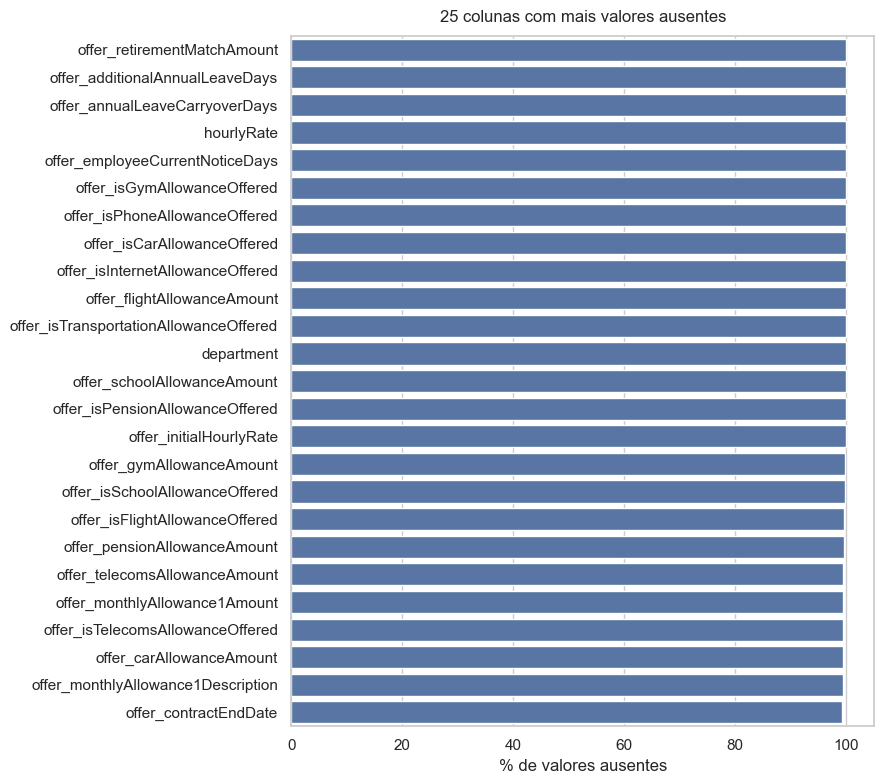

In [650]:
top_nulos = nulos.head(25)
fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=top_nulos.values, y=top_nulos.index, ax=ax, color=ACCENT)
ax.set_xlabel('% de valores ausentes')
ax.set_ylabel('')
ax.set_title('25 colunas com mais valores ausentes')
plt.tight_layout()
plt.show()

In [651]:
print(f'Colunas sem nenhum valor ausente : {(nulos == 0).sum()} de {len(nulos)}')
print(f'Colunas 100% vazias              : {(nulos == 100).sum()}')
nulos[nulos == 100]

Colunas sem nenhum valor ausente : 21 de 125
Colunas 100% vazias              : 5


offer_retirementMatchAmount        100.0
offer_additionalAnnualLeaveDays    100.0
offer_annualLeaveCarryoverDays     100.0
hourlyRate                         100.0
offer_employeeCurrentNoticeDays    100.0
dtype: float64

> **Leitura dos dados ausentes**
>
> - A maior parte dos campos `offer_*Allowance*` (benefícios opcionais, ex.:
>   `offer_gymAllowanceAmount`, `offer_carAllowanceAmount`) está 95–100% vazia — isso é esperado,
>   já que só é preenchida quando o benefício é de fato oferecido; não é um erro de coleta.
> - `hourlyRate` está 100% vazia nesta base e será desconsiderada da análise numérica.
> - `department` (99,9%) e `offer_jobIndustry` (94,9%) estão vazias demais para leitura confiável
>   e ficam fora do recorte de atributos-chave.
> - Colunas de identificação, status e localização (`id`, `status`, `country`, `payFrequency`,
>   `solutionType`) não têm nenhum valor ausente.

### Dados Duplicados

In [652]:
print('Linhas totalmente duplicadas :', df.duplicated().sum())
print('Linhas com `id` duplicado    :', df.duplicated(subset=['id']).sum())

Linhas totalmente duplicadas : 0
Linhas com `id` duplicado    : 21866


In [653]:
dup_ids = df[df.duplicated(subset=['id'], keep=False)]
print(f'{dup_ids["id"].nunique():,} valores de id aparecem mais de uma vez '
      f'({len(dup_ids):,} linhas no total).')

exemplo_id = dup_ids['id'].iloc[0]
grupo = df[df['id'] == exemplo_id]
colunas_diferentes = grupo.nunique(dropna=False)
colunas_diferentes = colunas_diferentes[colunas_diferentes > 1].index.tolist()
print(f'\nExemplo — id "{exemplo_id}" aparece {len(grupo)}x; colunas que diferem entre as linhas:')
print(colunas_diferentes)

21,854 valores de id aparecem mais de uma vez (43,720 linhas no total).

Exemplo — id "emp_6dEn01z5kG3bWwBuMEfkRP" aparece 2x; colunas que diferem entre as linhas:
['updatedAt', 'updatedBy', 'createdBy', 'jobId', 'contractId', 'startRequestId', 'offer_companyName', 'offer_updatedByIp']


> **Por que existem `id`s repetidos, mas nenhuma linha duplicada?**
>
> Este arquivo é a união de dois exports sintéticos gerados de forma independente (dev + staging,
> ver `nb_data_preparation.ipynb`). Os valores de `id` colidem entre os dois arquivos por serem
> identificadores sintéticos sorteados separadamente em cada ambiente — **não representam o
> mesmo evento de contratação duplicado**, como o exemplo acima confirma (linhas com o mesmo `id`
> têm `createdBy`, `contractId`, `offer_companyName` etc. diferentes). Não há, portanto,
> duplicidade real de registros nesta base.

## Estatística Descritiva

Com a estrutura da base mapeada, selecionamos um conjunto de **atributos-chave** — categóricos e
numéricos — para aprofundar a análise. Critério de seleção: (1) completude razoável (evitamos
campos com mais de ~90% de valores ausentes) e (2) relevância para o problema descrito na
Introdução (perfil da contratação/proposta e sua relação com o status).

- **Categóricos:** `status`, `onboarding_status`, `country`, `payFrequency`, `solutionType`,
  `period`, `payrollCurrencyCode`.
- **Numéricos:** `annualGrossSalary`, `offer_workingHoursPerWeek`, `offer_probationaryPeriodLength`.

In [654]:
COLS_CATEGORICAS = ['status', 'onboarding_status', 'country', 'payFrequency',
                     'solutionType', 'period', 'payrollCurrencyCode']
COLS_NUMERICAS = ['annualGrossSalary', 'offer_workingHoursPerWeek', 'offer_probationaryPeriodLength']

In [655]:
df[COLS_NUMERICAS].describe()

,annualGrossSalary,offer_workingHoursPerWeek,offer_probationaryPeriodLength
count,3.085000e+04,21163.000000,33835.000000
mean,2.628959e+06,40.365969,17.152800
std,4.704108e+07,27.354316,34.060376
min,0.000000e+00,0.000000,-3.000000
25%,6.912500e+03,40.000000,2.000000
50%,1.600000e+04,40.000000,3.000000
75%,1.000000e+05,40.000000,6.000000
max,5.068292e+09,4000.000000,365.000000


In [656]:
df[COLS_CATEGORICAS].describe()

,status,onboarding_status,country,payFrequency,solutionType,period,payrollCurrencyCode
count,73852,62302,73852,73852,73852,44539,71848
unique,10,5,162,5,3,12,124
top,hiring_process,completed,CA,monthly,Supported Employee,indefinite,CAD
freq,24086,28919,14311,36269,72506,39415,14231


In [657]:
def resumo_estatistico(col):
    s = df[col].dropna()
    if col == 'annualGrossSalary':
        s = s[s > 0]   # remove zeros/negativos espúrios de um campo monetário
    q1, q3 = s.quantile([0.25, 0.75])
    return pd.Series({
        'n': s.count(),
        'média': s.mean(),
        'mediana': s.median(),
        'moda': s.mode().iloc[0],
        'desvio_padrão': s.std(),
        'variância': s.var(),
        'IQR': q3 - q1,
        'assimetria': s.skew(),
        'curtose': s.kurt(),
    })

pd.DataFrame({col: resumo_estatistico(col) for col in COLS_NUMERICAS}).round(2)

,annualGrossSalary,offer_workingHoursPerWeek,offer_probationaryPeriodLength
n,2.975100e+04,21163.00,33835.00
média,2.726073e+06,40.37,17.15
mediana,1.750000e+04,40.00,3.00
moda,8.333330e+03,40.00,3.00
desvio_padrão,4.789931e+07,27.35,34.06
variância,2.294344e+15,748.26,1160.11
IQR,9.750000e+04,0.00,4.00
assimetria,8.357000e+01,143.34,2.44
curtose,8.500820e+03,20750.12,6.42


> **Como ler esta tabela**
>
> - `annualGrossSalary`: média muito acima da mediana e curtose altíssima — sinal de assimetria
>   extrema. A causa não é orgânica: o campo mistura **dezenas de moedas diferentes**
>   (`payrollCurrencyCode`) sem qualquer conversão, então a mesma magnitude numérica representa
>   valores completamente diferentes em CAD, EUR ou KRW. Aprofundamos isso na próxima seção,
>   comparando por moeda em vez de converter (nenhuma coluna nova é criada).
> - `offer_workingHoursPerWeek`: mediana de 40h é plausível, mas desvio padrão e assimetria
>   indicam outliers fortes (ver seção de variáveis numéricas).
> - `offer_probationaryPeriodLength`: mediana de poucos dias, mas o mínimo é negativo — um valor
>   claramente inválido para um período de experiência, também tratado a seguir.

## Análise das Variáveis Categóricas

Para cada atributo categórico-chave: distribuição de frequência (contagem e %) e o respectivo
gráfico de barras.

In [658]:
def analisar_categorica(col, top_n=12):
    freq = df[col].value_counts(dropna=False).head(top_n)
    freq_pct = (freq / len(df) * 100).round(1)

    print(f'\n### {col} ###')
    print(f'Valores únicos: {df[col].nunique()}  |  Ausentes: {df[col].isnull().mean()*100:.1f}%')
    display(pd.DataFrame({'contagem': freq, '%': freq_pct}))

    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(freq))))
    sns.barplot(x=freq.values, y=freq.index.astype(str), ax=ax, color=ACCENT)
    ax.set_xlabel('Contagem')
    ax.set_ylabel('')
    ax.set_title(col)
    plt.tight_layout()
    plt.show()


### status ###
Valores únicos: 10  |  Ausentes: 0.0%


,contagem,%
status,,
hiring_process,24086,32.6
working,18487,25.0
terminated,12512,16.9
resigned,8871,12.0
lost,6407,8.7
transferred,2018,2.7
completed,1084,1.5
duplicate,229,0.3
ready_to_start,151,0.2


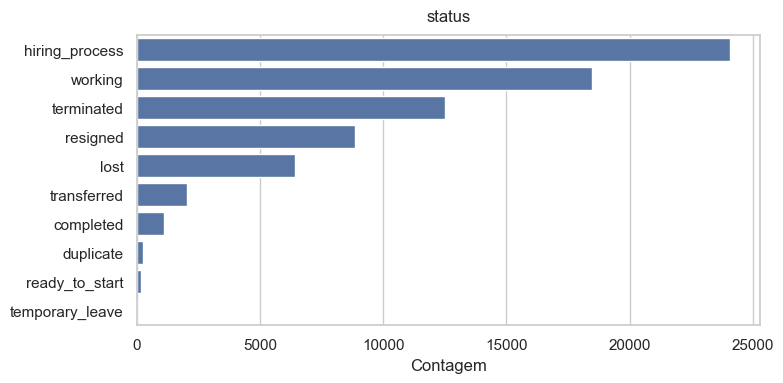


### onboarding_status ###
Valores únicos: 5  |  Ausentes: 15.6%


,contagem,%
onboarding_status,,
completed,28919,39.2
in_progress,21978,29.8
NaN,11550,15.6
lost,5947,8.1
pending_deposit,5234,7.1
duplicate,224,0.3


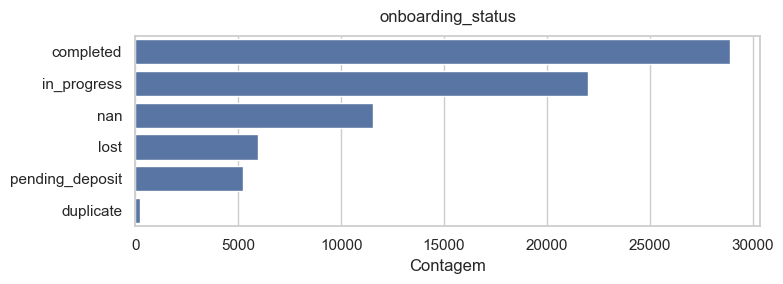


### country ###
Valores únicos: 162  |  Ausentes: 0.0%


,contagem,%
country,,
CA,14311,19.4
GB,5513,7.5
IN,4332,5.9
AU,4256,5.8
BR,3996,5.4
US,3281,4.4
MX,2926,4.0
FR,2515,3.4
ES,2215,3.0


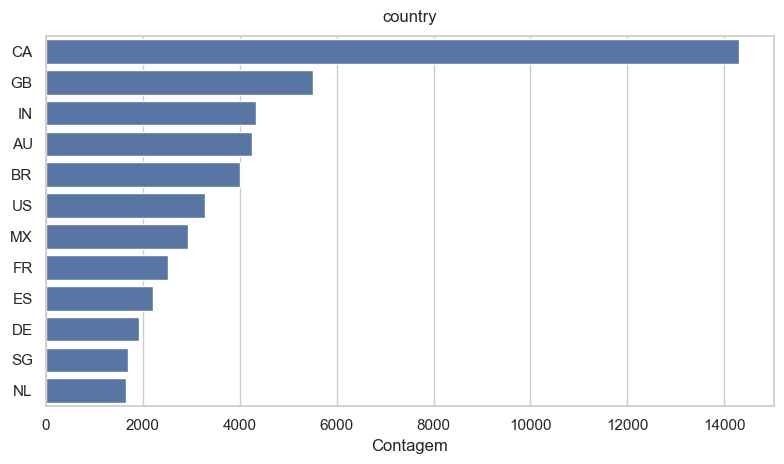


### payFrequency ###
Valores únicos: 5  |  Ausentes: 0.0%


,contagem,%
payFrequency,,
monthly,36269,49.1
no_payroll_frequency,31027,42.0
semi_monthly,6237,8.4
bi_weekly,262,0.4
weekly,57,0.1


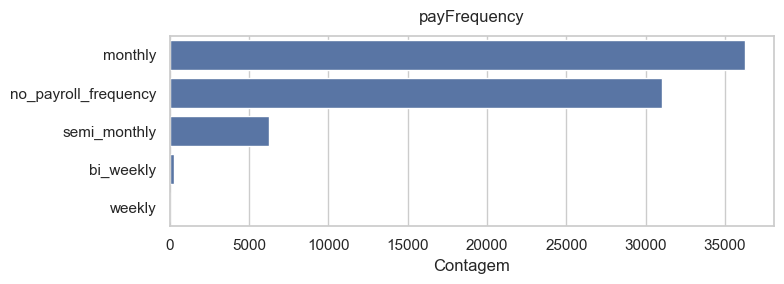


### solutionType ###
Valores únicos: 3  |  Ausentes: 0.0%


,contagem,%
solutionType,,
Supported Employee,72506,98.2
Multi-Country Payroll,1150,1.6
Contractor Payments,196,0.3


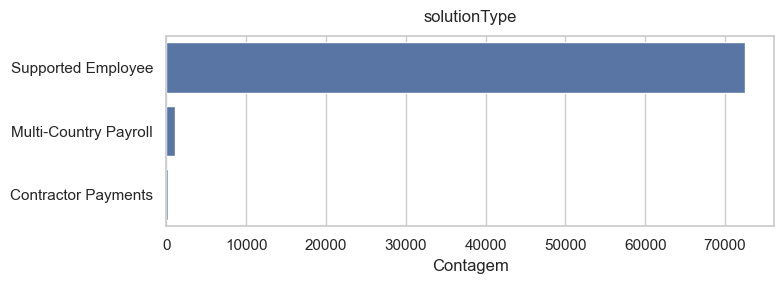


### period ###
Valores únicos: 12  |  Ausentes: 39.7%


,contagem,%
period,,
indefinite,39415,53.4
NaN,29313,39.7
fixed_term,3700,5.0
three_year_fixed_term,390,0.5
three_month_fixed,200,0.3
unknown,168,0.2
contractor,126,0.2
twelve_fixed_auto_renewal,124,0.2
fixed_term_back_to_back,96,0.1


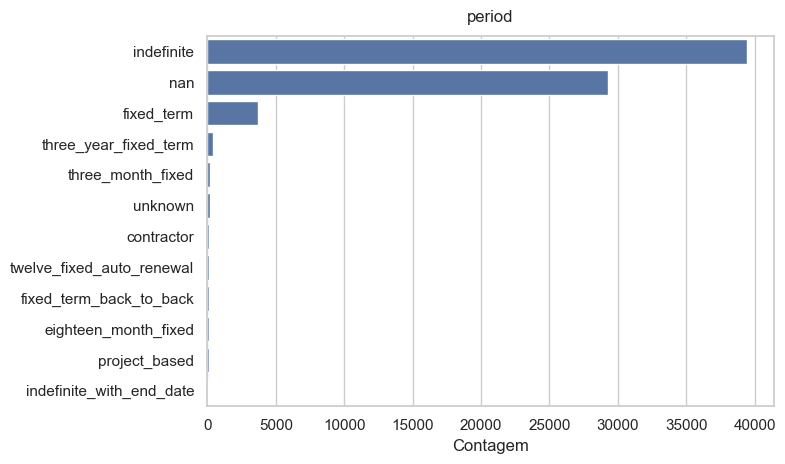


### payrollCurrencyCode ###
Valores únicos: 124  |  Ausentes: 2.7%


,contagem,%
payrollCurrencyCode,,
CAD,14231,19.3
EUR,12203,16.5
GBP,5444,7.4
INR,4287,5.8
AUD,4185,5.7
BRL,3933,5.3
USD,3041,4.1
MXN,2889,3.9
NaN,2004,2.7


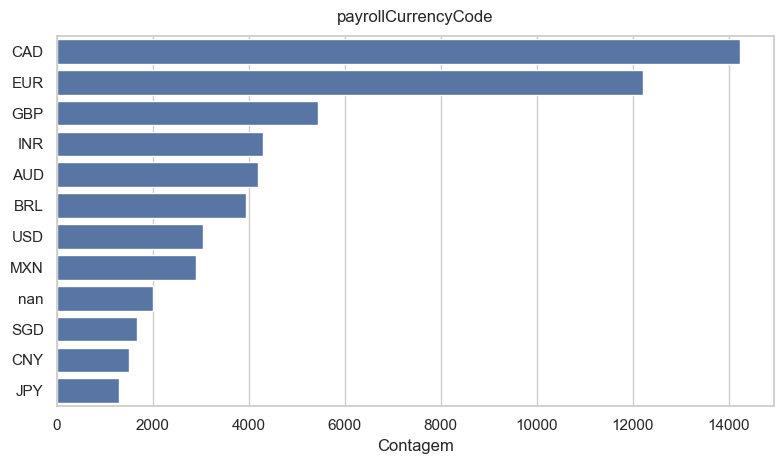

In [659]:
for col in COLS_CATEGORICAS:
    analisar_categorica(col)

### Relação entre `status` e as Demais Categóricas

Como definido na Introdução, usamos o `status` tal como ele existe na base (sem criar uma
categoria nova de "resultado") para ver como ele se distribui dentro de cada atributo-chave.

In [660]:
def status_por_categoria(col, top_n=8):
    top_vals = df[col].value_counts().head(top_n).index
    sub = df[df[col].isin(top_vals)]
    tab = pd.crosstab(sub[col], sub['status'], normalize='index').round(3) * 100
    tab = tab.loc[top_vals]

    fig, ax = plt.subplots(figsize=(10, 5))
    tab.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_ylabel('% de linhas')
    ax.set_xlabel(col)
    ax.set_title(f'Distribuição de status dentro de cada {col}')
    ax.legend(title='status', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return tab.round(1)

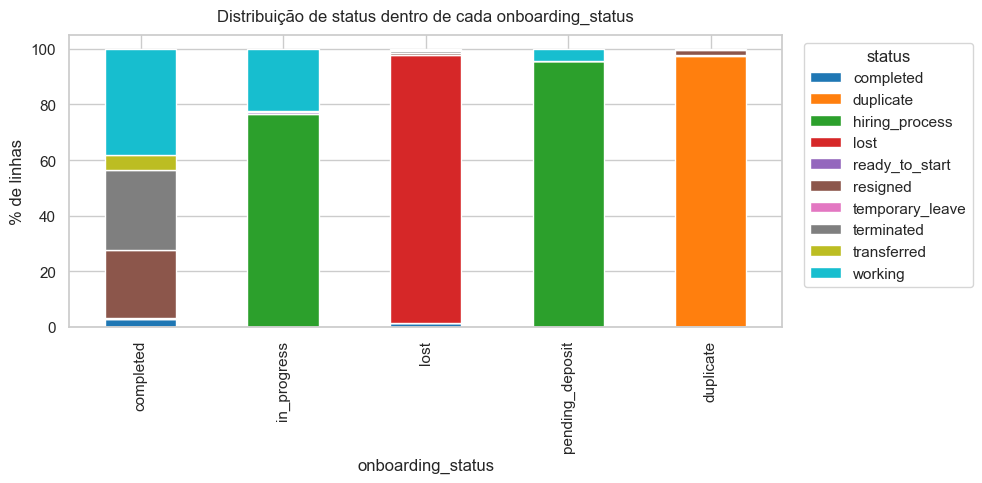

status,completed,duplicate,hiring_process,lost,ready_to_start,resigned,temporary_leave,terminated,transferred,working
onboarding_status,,,,,,,,,,
completed,2.8,0.0,0.1,0.2,0.0,24.7,0.0,28.6,5.4,38.2
in_progress,0.1,0.0,76.5,0.0,0.7,0.1,0.0,0.3,0.0,22.3
lost,1.3,0.1,0.1,96.2,0.0,0.7,0.0,1.0,0.1,0.5
pending_deposit,0.0,0.0,95.5,0.1,0.1,0.1,0.0,0.0,0.0,4.2
duplicate,0.0,97.3,0.4,0.0,0.0,1.8,0.0,0.0,0.0,0.4


In [661]:
status_por_categoria('onboarding_status')

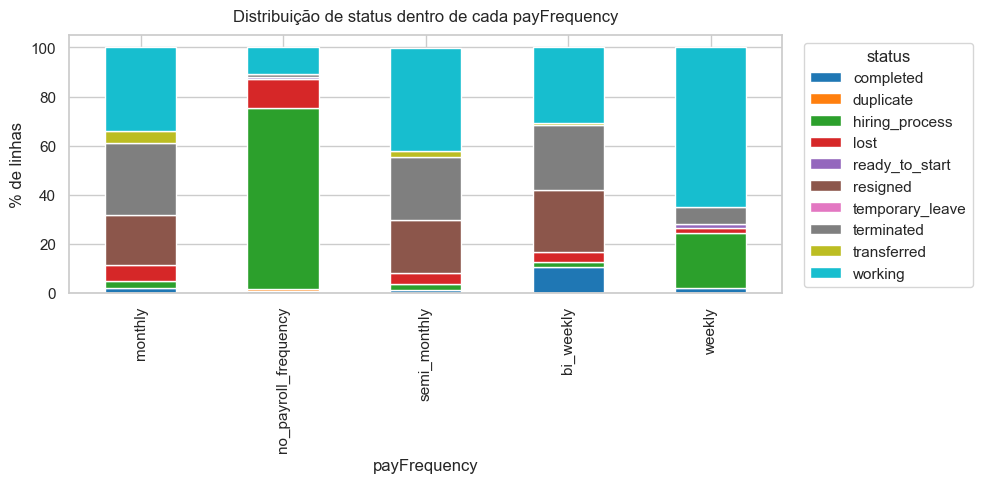

status,completed,duplicate,hiring_process,lost,ready_to_start,resigned,temporary_leave,terminated,transferred,working
payFrequency,,,,,,,,,,
monthly,2.1,0.0,2.8,6.5,0.0,20.4,0.0,29.1,4.9,34.2
no_payroll_frequency,0.7,0.7,73.8,12.1,0.5,0.2,0.0,1.0,0.2,10.8
semi_monthly,1.3,0.0,2.5,4.4,0.0,21.6,0.0,25.5,2.5,42.1
bi_weekly,10.7,0.0,1.9,4.2,0.0,25.2,0.0,26.3,0.8,30.9
weekly,1.8,0.0,22.8,1.8,1.8,0.0,0.0,7.0,0.0,64.9


In [662]:
status_por_categoria('payFrequency')

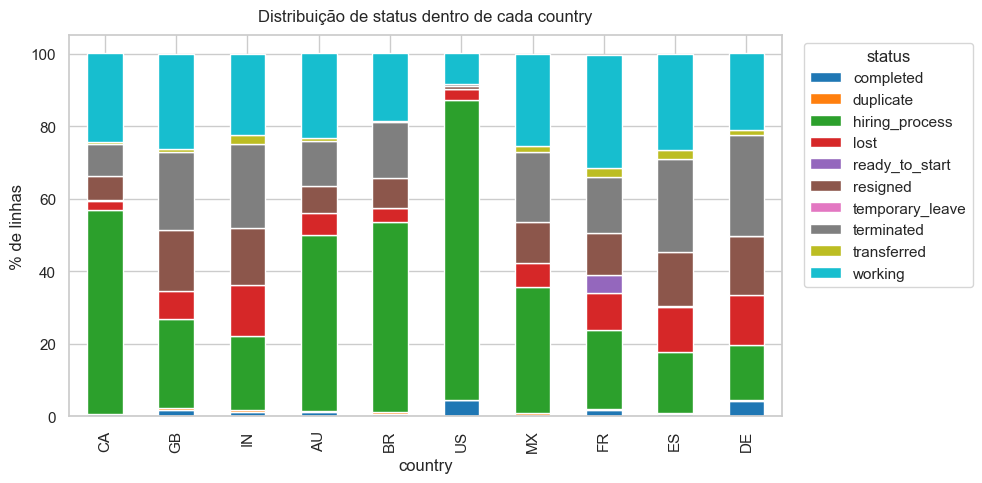

status,completed,duplicate,hiring_process,lost,ready_to_start,resigned,temporary_leave,terminated,transferred,working
country,,,,,,,,,,
CA,0.6,0.2,56.0,2.7,0.1,6.7,0.0,8.7,0.6,24.6
GB,1.7,0.6,24.6,7.7,0.0,16.8,0.0,21.6,0.7,26.3
IN,1.2,0.5,20.4,14.2,0.0,15.6,0.0,23.1,2.7,22.3
AU,1.2,0.4,48.5,5.9,0.0,7.6,0.0,12.3,0.8,23.4
BR,0.7,0.4,52.4,3.9,0.1,8.2,0.0,15.5,0.4,18.5
US,4.5,0.1,82.7,3.0,0.1,0.8,0.0,0.4,0.0,8.6
MX,0.4,0.5,34.9,6.4,0.0,11.5,0.0,19.2,1.7,25.4
FR,1.9,0.2,21.7,10.2,5.0,11.5,0.0,15.4,2.6,31.3
ES,0.8,0.1,16.8,12.6,0.1,15.0,0.0,25.6,2.6,26.4


In [663]:
status_por_categoria('country', top_n=10)

## Análise das Variáveis Numéricas

Aqui olhamos a forma da distribuição de cada atributo numérico-chave (histogramas), possíveis
outliers e a relação com `status`.

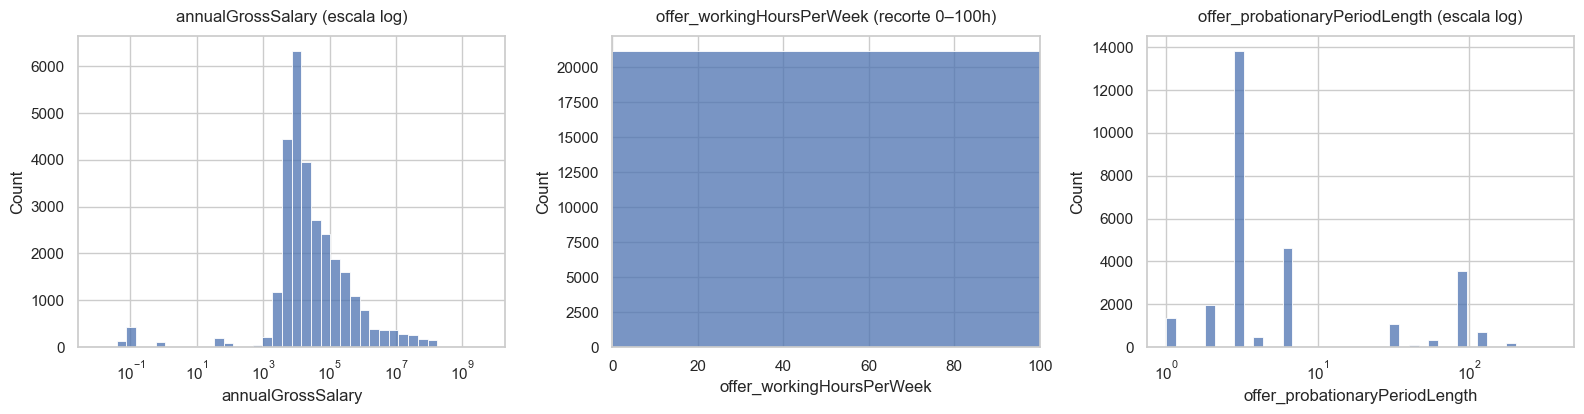

In [664]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

salario = df.loc[df['annualGrossSalary'] > 0, 'annualGrossSalary'].dropna()
sns.histplot(salario, ax=axes[0], color=ACCENT, bins=40, log_scale=True)
axes[0].set_title('annualGrossSalary (escala log)')

horas = df['offer_workingHoursPerWeek'].dropna()
sns.histplot(horas, ax=axes[1], color=ACCENT, bins=40)
axes[1].set_xlim(0, 100)
axes[1].set_title('offer_workingHoursPerWeek (recorte 0–100h)')

prob = df.loc[df['offer_probationaryPeriodLength'] > 0, 'offer_probationaryPeriodLength'].dropna()
sns.histplot(prob, ax=axes[2], color=ACCENT, bins=40, log_scale=True)
axes[2].set_title('offer_probationaryPeriodLength (escala log)')

plt.tight_layout()
plt.show()

#### `annualGrossSalary` por Moeda

In [665]:
por_moeda = (
    df[df['annualGrossSalary'] > 0]
    .groupby('payrollCurrencyCode')['annualGrossSalary']
    .agg(contagem='count', mediana='median', media='mean', desvio_padrao='std')
    .sort_values('contagem', ascending=False)
    .head(10)
)
por_moeda.round(1)

,contagem,mediana,media,desvio_padrao
payrollCurrencyCode,,,,
EUR,5837,7000.0,15067.1,151673.4
GBP,2879,7161.5,10393.2,16741.1
CAD,2744,12096.5,257680.1,8725252.8
INR,2294,279220.3,617801.1,3664731.6
MXN,1198,81485.1,142873.5,842000.5
BRL,1094,27000.0,258768.1,5260747.7
AUD,1068,12179.8,19746.0,44683.3
USD,922,10728.1,1278727.2,8464831.2
CNY,808,28333.3,37175.9,32440.8


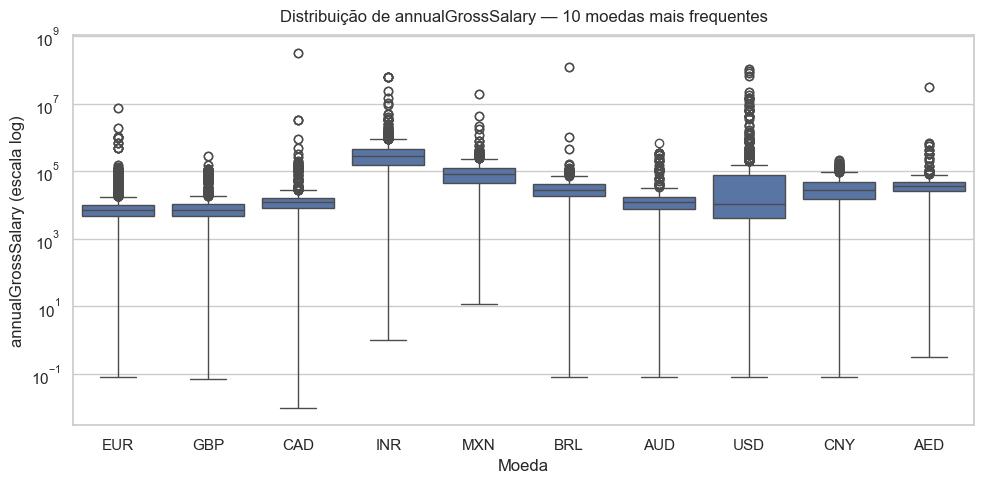

In [666]:
top_moedas = por_moeda.index.tolist()
plot_df = df[df['payrollCurrencyCode'].isin(top_moedas) & (df['annualGrossSalary'] > 0)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=plot_df, x='payrollCurrencyCode', y='annualGrossSalary', order=top_moedas, ax=ax, color=ACCENT)
ax.set_yscale('log')
ax.set_xlabel('Moeda')
ax.set_ylabel('annualGrossSalary (escala log)')
ax.set_title('Distribuição de annualGrossSalary — 10 moedas mais frequentes')
plt.tight_layout()
plt.show()

#### Outliers em `offer_workingHoursPerWeek`

In [667]:
q1h, q3h = horas.quantile([0.25, 0.75])
iqrh = q3h - q1h
lim_sup_h = q3h + 1.5 * iqrh
outliers_h = horas[horas > lim_sup_h]

# 168h = 24h x 7 dias — teto físico absoluto de uma semana, um critério mais direto que o
# IQR aqui (Q1 = Q3 = 40, então a regra do IQR classifica qualquer valor != 40 como outlier)
impossiveis = horas[horas > 168]

print(f'n = {len(horas):,}  |  mínimo = {horas.min():.0f}  |  máximo = {horas.max():.0f}')
print(f'Q1 = {q1h:.0f}  |  Q3 = {q3h:.0f}  |  IQR = {iqrh:.0f}')
print(f'Regra do IQR   → limite superior = {lim_sup_h:.0f}h/semana → {len(outliers_h)} linhas acima disso ({len(outliers_h)/len(horas)*100:.2f}%)')
print(f'Teto físico    → valores > 168h/semana = {len(impossiveis)} ({len(impossiveis)/len(horas)*100:.3f}%)')
print(f'Maiores valores encontrados: {sorted(horas.unique())[-5:]}')

n = 21,163  |  mínimo = 0  |  máximo = 4000
Q1 = 40  |  Q3 = 40  |  IQR = 0
Regra do IQR   → limite superior = 40h/semana → 2499 linhas acima disso (11.81%)
Teto físico    → valores > 168h/semana = 1 (0.005%)
Maiores valores encontrados: [np.float64(53.0), np.float64(70.0), np.float64(80.0), np.float64(90.0), np.float64(4000.0)]


> A regra do IQR sinaliza muitas linhas porque `Q1 = Q3 = 40` (a maioria das respostas é
> exatamente 40h) — qualquer desvio, mesmo plausível (ex.: 45h, 50h), já entra como "outlier"
> técnico. O critério do teto físico (168h/semana) é mais direto: isola exatamente **1 registro**
> (4000h/semana) como erro de dado real, sem marcar jornadas apenas atípicas.

#### Relação com `status`

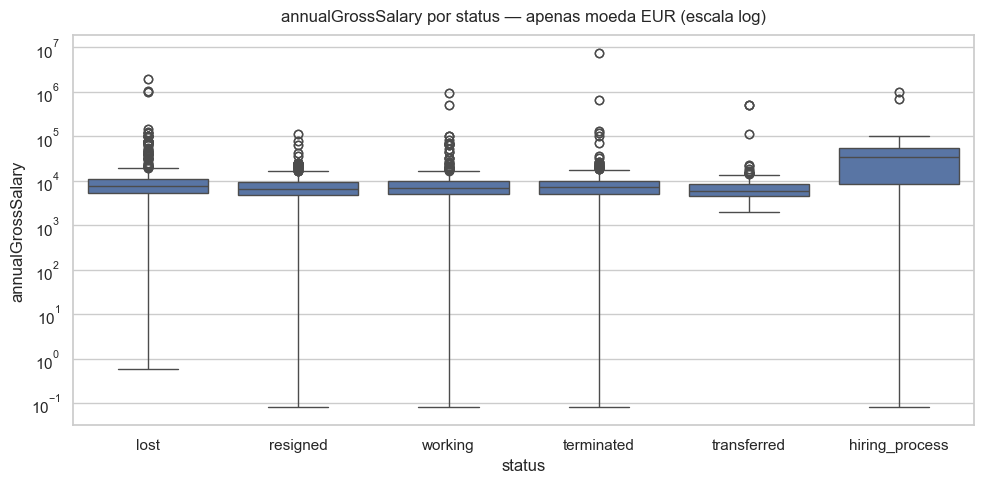

In [668]:
# Comparação dentro de uma única moeda (a mais frequente) para não misturar escalas
moeda_ref = por_moeda.index[0]
sub = df[(df['payrollCurrencyCode'] == moeda_ref) & (df['annualGrossSalary'] > 0) &
         df['status'].isin(df['status'].value_counts().head(6).index)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sub, x='status', y='annualGrossSalary', ax=ax, color=ACCENT)
ax.set_yscale('log')
ax.set_title(f'annualGrossSalary por status — apenas moeda {moeda_ref} (escala log)')
plt.tight_layout()
plt.show()

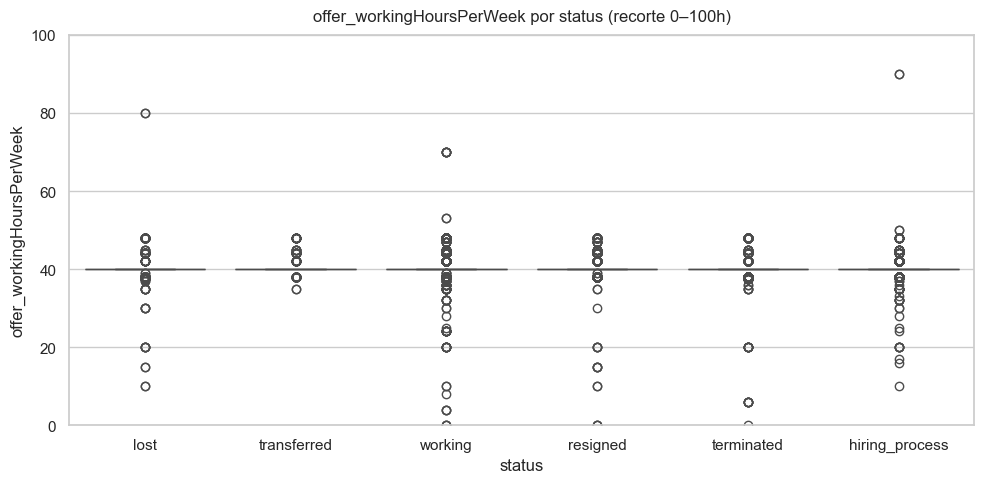

In [669]:
sub_horas = df[df['status'].isin(df['status'].value_counts().head(6).index)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sub_horas, x='status', y='offer_workingHoursPerWeek', ax=ax, color=ACCENT)
ax.set_ylim(0, 100)
ax.set_title('offer_workingHoursPerWeek por status (recorte 0–100h)')
plt.tight_layout()
plt.show()

#### Correlação entre as Variáveis Numéricas-Chave

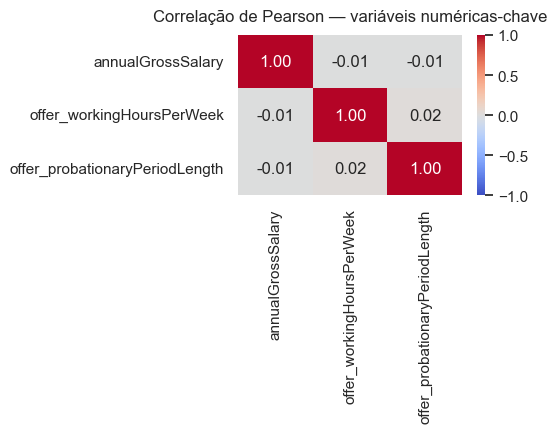

In [670]:
corr = df[COLS_NUMERICAS].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlação de Pearson — variáveis numéricas-chave')
plt.tight_layout()
plt.show()

## Conclusão

**Estrutura da base**
- 73.852 linhas × 125 colunas; a maioria (85) é `object`, com 34 colunas `float64` — mas várias
  destas são identificadores (não variáveis numéricas de fato) e algumas colunas de data estão
  guardadas como texto.
- `status` e `engagementStatus` são idênticas; usamos apenas `status`.

**Qualidade dos dados**
- Sem linhas totalmente duplicadas. Os ids repetidos entre si têm explicação conhecida (união de
  duas fontes sintéticas independentes — dev + staging) e não representam duplicidade real.
- Boa parte dos campos `offer_*` (benefícios opcionais) é esparsa por natureza; `hourlyRate` está
  100% vazia; `department` e `offer_jobIndustry` vazias demais para leitura confiável.

**Atributos-chave**
- Categóricos: `status` é dominado por `hiring_process`, `working` e `terminated`;
  `onboarding_status` por `completed` e `in_progress`; `country` tem cauda longa (162 valores);
  `payFrequency` é majoritariamente `monthly`; `solutionType` é dominado por
  `Supported Employee` (~98%); os principais `payrollCurrencyCode` são CAD, EUR e GBP.
- Numéricos: `annualGrossSalary` é fortemente assimétrico por misturar moedas — a mediana por
  moeda é uma leitura mais confiável que a média geral. `offer_workingHoursPerWeek` tem 1 registro
  fisicamente impossível (4000h/semana); a regra do IQR sozinha exagera o problema porque a
  maioria das respostas está concentrada exatamente em 40h. `offer_probationaryPeriodLength`
  tem ao menos um valor negativo, também inválido.
- As tabelas e gráficos de `status_por_categoria` e os boxplots por `status` mostram, sem criar
  nenhuma variável nova, como a distribuição de status varia entre `onboarding_status`,
  `payFrequency`, país, salário (dentro de uma mesma moeda) e carga horária — a base de onde
  qualquer investigação de causa/associação mais profunda pode partir.

**Próximos passos sugeridos:** limpar os outliers inválidos identificados (`offer_workingHoursPerWeek`,
`offer_probationaryPeriodLength`) antes de qualquer modelagem, e — se for necessário comparar
salários entre moedas de forma justa — introduzir uma conversão cambial (fora do escopo deste
notebook, puramente descritivo). Para testes de associação estatística entre atributos e o
resultado da contratação, ver `nb_employment_offer_analysis.ipynb`.